# Dax Virani | Superstore Sales Intelligence
A business-ready notebook with synthetic data fallback, time-based revenue analysis, profitability diagnostics, and regional/category insights.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA",
    "axes.facecolor": "#FFFFFF",
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold"
})

DATA_PATH = Path("superstore.csv")
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
else:
    rng = np.random.default_rng(42)
    categories = {"Furniture": ["Bookcases", "Chairs", "Furnishings", "Tables"], "Office Supplies": ["Appliances", "Art", "Binders", "Envelopes", "Fasteners", "Labels", "Paper", "Storage", "Supplies"], "Technology": ["Accessories", "Copiers", "Machines", "Phones"]}
    products = {"Bookcases": ["Sauder Bookcases", "Bush Bookcases"], "Chairs": ["Hon Executive Chair", "Global Leather Chair"], "Furnishings": ["Eldon Shelf", "Tensor Lamp"], "Tables": ["Bevis Computer Table", "Lesro Table"], "Appliances": ["Hoover Stove", "Fellowes Shredder"], "Art": ["Fiskars Scissors", "Sanford Pencils"], "Binders": ["Avery Heavy Binders", "Cardinal Slant-D Binders"], "Envelopes": ["Wausau Astrobright Envelopes"], "Fasteners": ["Advantus Push Pins", "OIC Staples"], "Labels": ["Avery Labels"], "Paper": ["Xerox Paper", "Hammermill Paper"], "Storage": ["Fellowes File Cabinet", "Eldon Jumbo Storage"], "Supplies": ["Boston Pencil Sharpener"], "Accessories": ["Logitech Mouse", "Kensington Keyboard"], "Copiers": ["HP LaserJet Copier"], "Machines": ["Cisco TelePresence"], "Phones": ["Apple iPhone", "Samsung Galaxy"]}
    margins = {"Bookcases": (-0.05, 0.10), "Chairs": (0.03, 0.08), "Furnishings": (0.10, 0.05), "Tables": (-0.10, 0.12), "Appliances": (0.12, 0.06), "Art": (0.18, 0.05), "Binders": (0.05, 0.12), "Envelopes": (0.20, 0.04), "Fasteners": (0.22, 0.04), "Labels": (0.25, 0.03), "Paper": (0.18, 0.05), "Storage": (0.08, 0.07), "Supplies": (-0.04, 0.10), "Accessories": (0.15, 0.06), "Copiers": (0.20, 0.08), "Machines": (0.04, 0.10), "Phones": (0.12, 0.07)}
    rows = []
    order_id = 1000
    for _ in range(9800):
        cat = rng.choice(list(categories))
        sub = rng.choice(categories[cat])
        m, s = margins[sub]
        sale = round(float(rng.uniform(5, 1500)) * int(rng.integers(1, 15)) * (1 - rng.choice([0, 0, 0, 0.1, 0.2, 0.3, 0.5])), 2)
        rows.append({
            "Order ID": f"CA-{order_id:05d}",
            "Order Date": pd.Timestamp("2020-01-01") + pd.Timedelta(days=int(rng.integers(0, 365 * 4))),
            "Ship Date": pd.Timestamp("2020-01-01") + pd.Timedelta(days=int(rng.integers(1, 8))),
            "Ship Mode": rng.choice(["Standard Class", "Second Class", "First Class", "Same Day"]),
            "Customer ID": f"CU-{int(rng.integers(1000, 9999)):04d}",
            "Segment": rng.choice(["Consumer", "Corporate", "Home Office"]),
            "Region": rng.choice(["East", "West", "Central", "South"]),
            "Product ID": f"P-{int(rng.integers(10000, 99999)):05d}",
            "Category": cat,
            "Sub-Category": sub,
            "Product Name": rng.choice(products[sub]),
            "Sales": sale,
            "Quantity": int(rng.integers(1, 15)),
            "Discount": round(float(rng.choice([0, 0, 0, 0.1, 0.2, 0.3, 0.5])), 2),
            "Profit": round(sale * float(np.clip(rng.normal(m, s), -0.5, 0.5)), 2)
        })
        order_id += 1
    df = pd.DataFrame(rows)
    df.to_csv(DATA_PATH, index=False)

df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-01000,2020-05-05,2020-01-06,Standard Class,CU-1847,Corporate,South,P-76216,Furniture,Tables,Lesro Table,2313.93,11,0.3,-236.06
1,CA-01001,2023-02-15,2020-01-06,Second Class,CU-8404,Corporate,West,P-50540,Technology,Copiers,HP LaserJet Copier,839.01,4,0.0,103.44
2,CA-01002,2023-01-11,2020-01-06,Second Class,CU-1611,Home Office,West,P-90380,Office Supplies,Storage,Eldon Jumbo Storage,11392.06,11,0.3,1335.85
3,CA-01003,2022-09-24,2020-01-08,First Class,CU-4299,Home Office,West,P-39323,Furniture,Chairs,Global Leather Chair,164.96,6,0.0,19.85
4,CA-01004,2020-11-27,2020-01-05,First Class,CU-9461,Corporate,East,P-84940,Office Supplies,Fasteners,OIC Staples,1432.36,10,0.0,276.99


## Cleaning and Feature Engineering
Dates are normalized, missing values are handled, and monthly grouping fields are added for trend analysis.

In [2]:
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include="object").columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])
for col in ["Order Date", "Ship Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Year-Month"] = df["Order Date"].dt.to_period("M")
df["Profit Margin %"] = (df["Profit"] / df["Sales"].replace(0, np.nan)) * 100
display(pd.DataFrame({"rows": [len(df)], "columns": [df.shape[1]], "missing": [int(df.isna().sum().sum())]}))
display(df[["Sales", "Profit", "Quantity", "Discount", "Profit Margin %"]].describe().round(2))

,rows,columns,missing
0,9800,19,0


,Sales,Profit,Quantity,Discount,Profit Margin %
count,9800.00,9800.00,9800.00,9800.00,9800.00
mean,4740.85,400.33,7.51,0.16,8.54
std,4224.09,900.34,4.03,0.18,12.92
min,4.89,-5575.05,1.00,0.00,-50.00
25%,1361.08,7.72,4.00,0.00,1.13
50%,3476.04,212.33,8.00,0.10,10.44
75%,6965.68,706.14,11.00,0.30,18.07
max,20956.22,6348.11,14.00,0.50,49.84


## Revenue and Profit Intelligence
The next block pairs trend views with category and sub-category profitability diagnostics.

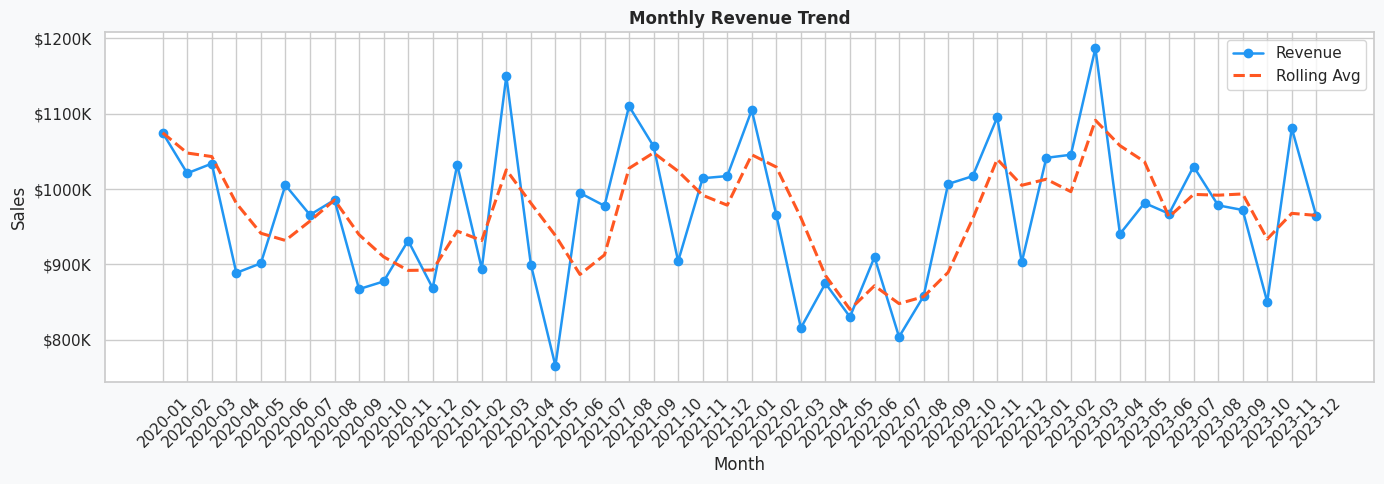

,Category,Sales,Profit,Margin %
1,Office Supplies,15505055.82,2149942.86,13.9
2,Technology,15462219.02,1921780.13,12.4
0,Furniture,15493063.49,-148453.51,-1.0


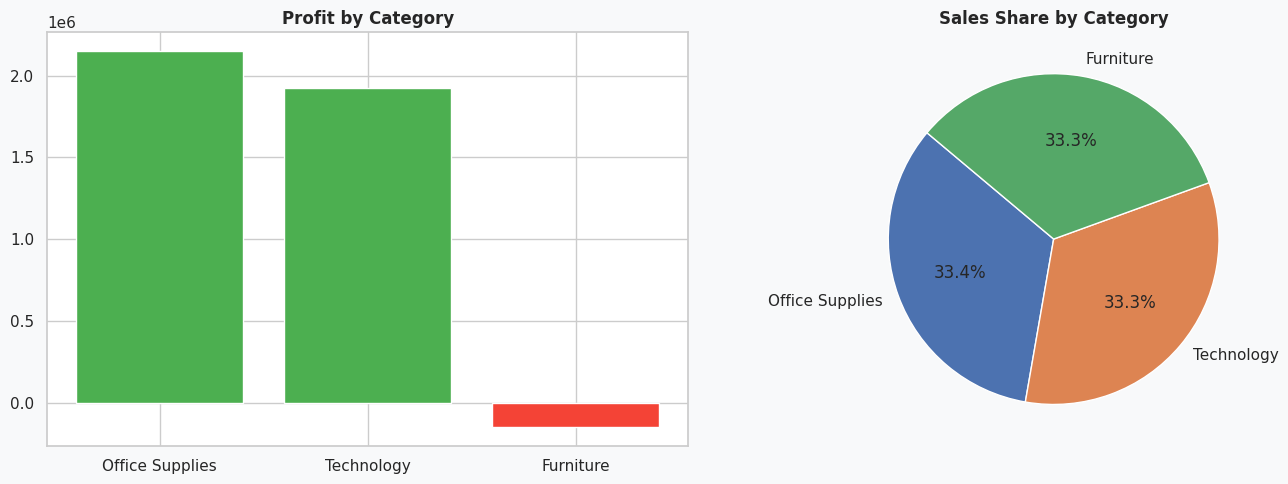

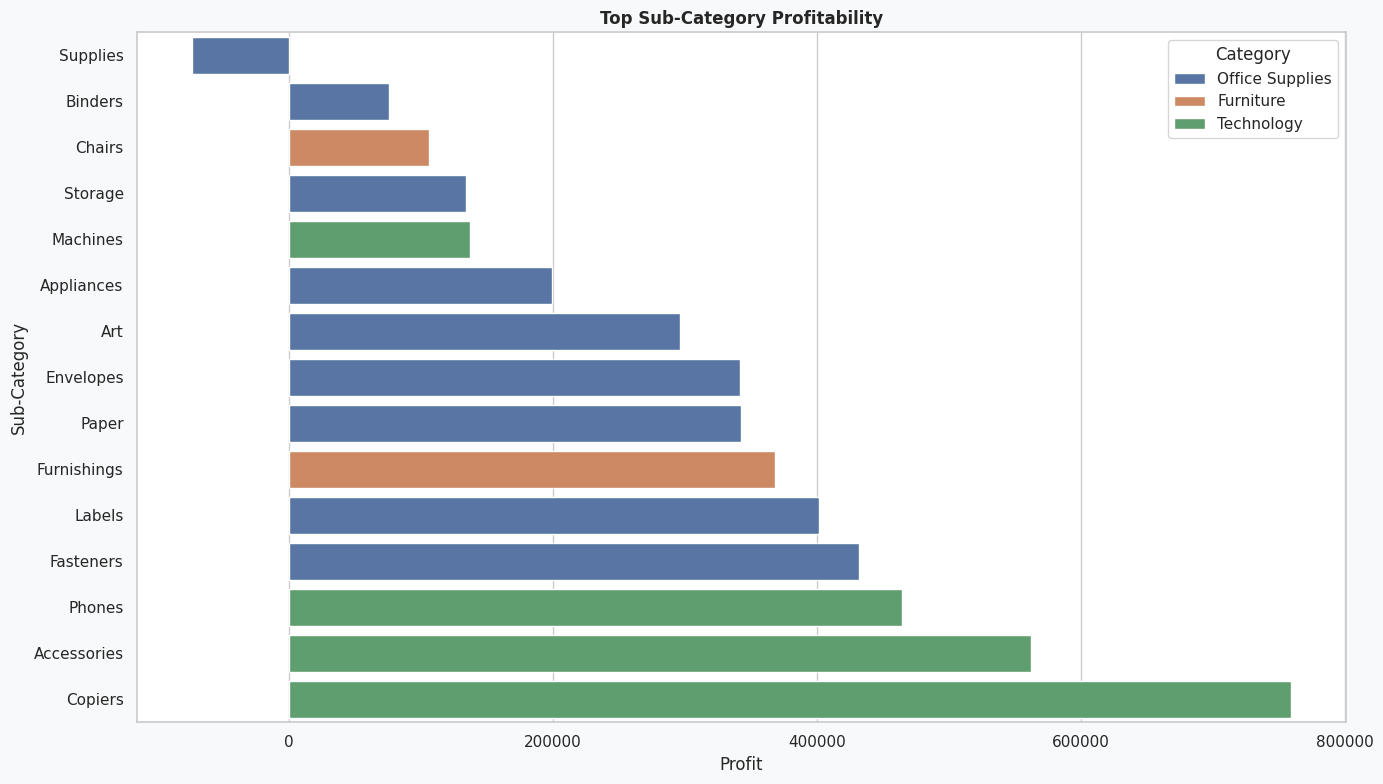

In [3]:
monthly = df.groupby("Year-Month")["Sales"].sum().reset_index().sort_values("Year-Month")
monthly["Year-Month Str"] = monthly["Year-Month"].astype(str)
monthly["Rolling Avg"] = monthly["Sales"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["Year-Month Str"], monthly["Sales"], marker="o", lw=1.8, color="#2196F3", label="Revenue")
ax.plot(monthly["Year-Month Str"], monthly["Rolling Avg"], lw=2.2, ls="--", color="#FF5722", label="Rolling Avg")
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

cat_profit = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index().sort_values("Profit", ascending=False)
cat_profit["Margin %"] = (cat_profit["Profit"] / cat_profit["Sales"] * 100).round(1)
display(cat_profit)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cat_profit["Category"], cat_profit["Profit"], color=["#4CAF50" if p > 0 else "#F44336" for p in cat_profit["Profit"]])
axes[0].set_title("Profit by Category")
axes[1].pie(cat_profit["Sales"], labels=cat_profit["Category"], autopct="%1.1f%%", startangle=140)
axes[1].set_title("Sales Share by Category")
plt.tight_layout()
plt.show()

sub_profit = df.groupby(["Category", "Sub-Category"])[["Sales", "Profit"]].sum().reset_index().sort_values("Profit")
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=sub_profit.tail(15), y="Sub-Category", x="Profit", hue="Category", dodge=False, ax=ax)
ax.set_title("Top Sub-Category Profitability")
plt.tight_layout()
plt.show()

## Operational Insights
The final summary surfaces the most useful slices for business review: region, ship mode, and discount impact.

In [4]:
display(df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False))
display(df.groupby("Ship Mode")[["Sales", "Profit"]].mean().round(2))
display(df[["Discount", "Sales", "Profit"]].corr().round(3))

,Sales,Profit
Region,,
Central,11729921.24,977546.23
South,11655598.71,1007429.45
West,11655460.46,976089.85
East,11419357.92,962203.95


,Sales,Profit
Ship Mode,,
First Class,4718.67,405.14
Same Day,4813.47,405.83
Second Class,4850.78,395.02
Standard Class,4582.86,395.51


,Discount,Sales,Profit
Discount,1.000,-0.005,-0.015
Sales,-0.005,1.000,0.396
Profit,-0.015,0.396,1.000
